# Figure 3: Copy # Correction

**Goal:**

Present the copy number correction story: Copy number correction amends differential replication effects on gene expression and chromatin.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [202]:
from src.Figure3_Copy_Correction import Figure3CopyCorrection
from src.figure_configs import save_figure_for_paper

figures = Figure3CopyCorrection()

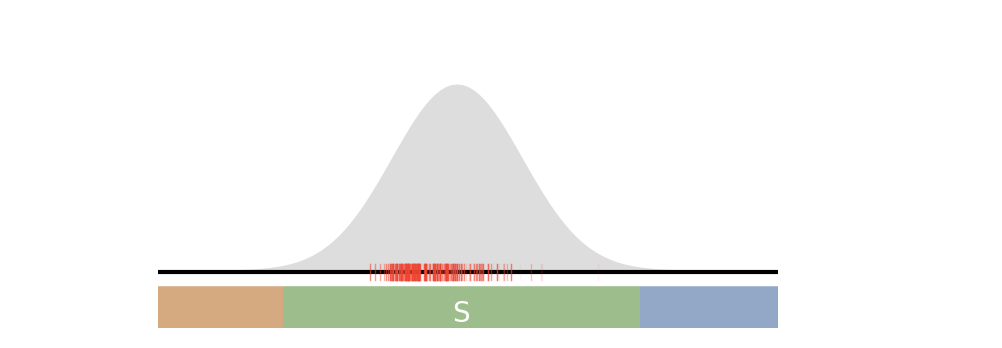

In [203]:
figures.plot_S_diagram()

10, 00:00:09.060
10, 00:00:08.807
Deconvolving with config: shared, <class 'src.single_G1_config.Config'>, <function calcH at 0x7fd5a21e5ee0>


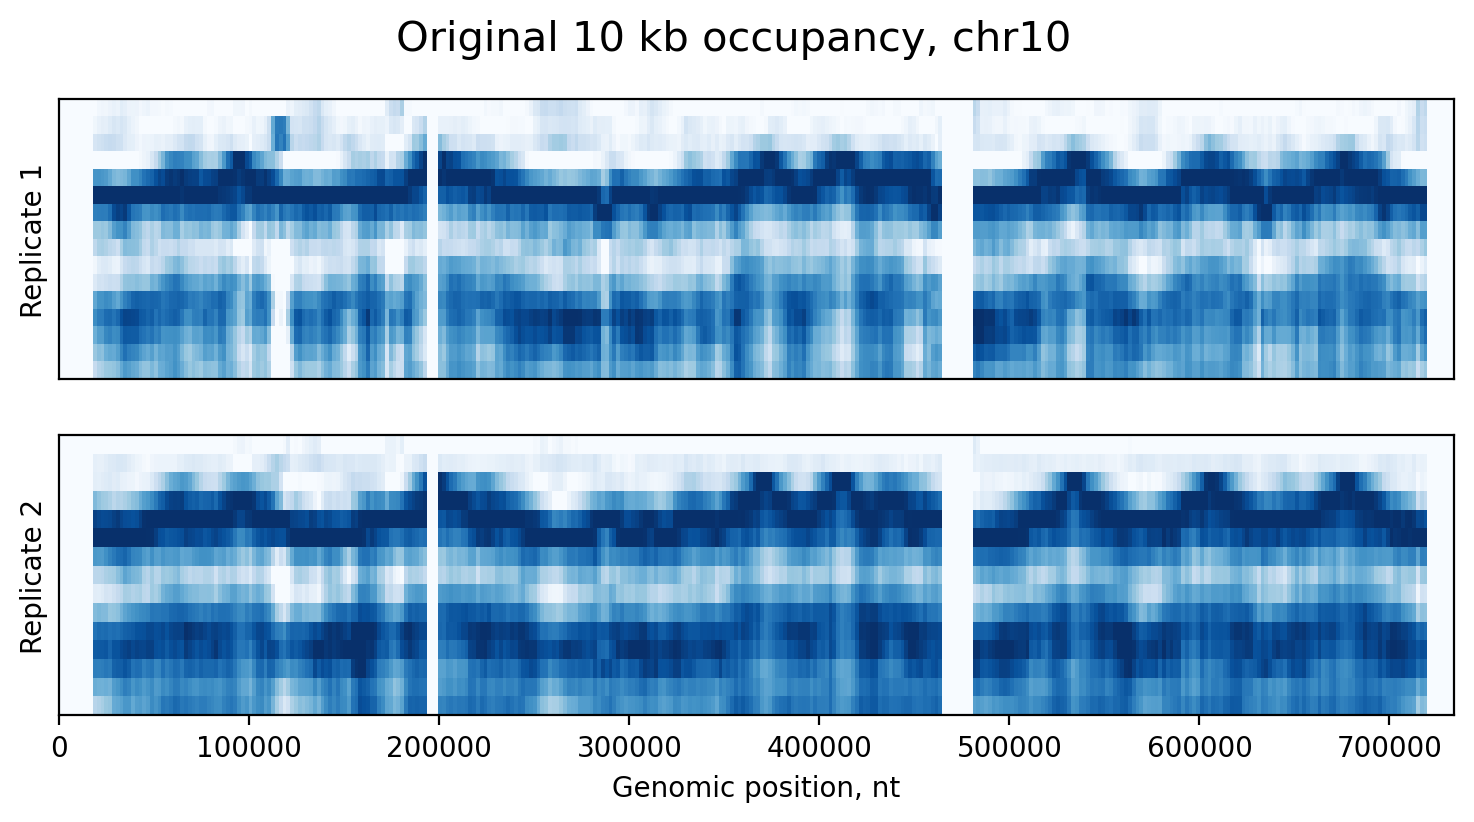

In [204]:
figures.plot_raw_replication_chr10()
save_figure_for_paper('output/figures/Copy_Correction/Raw_10kb_chr10.png')

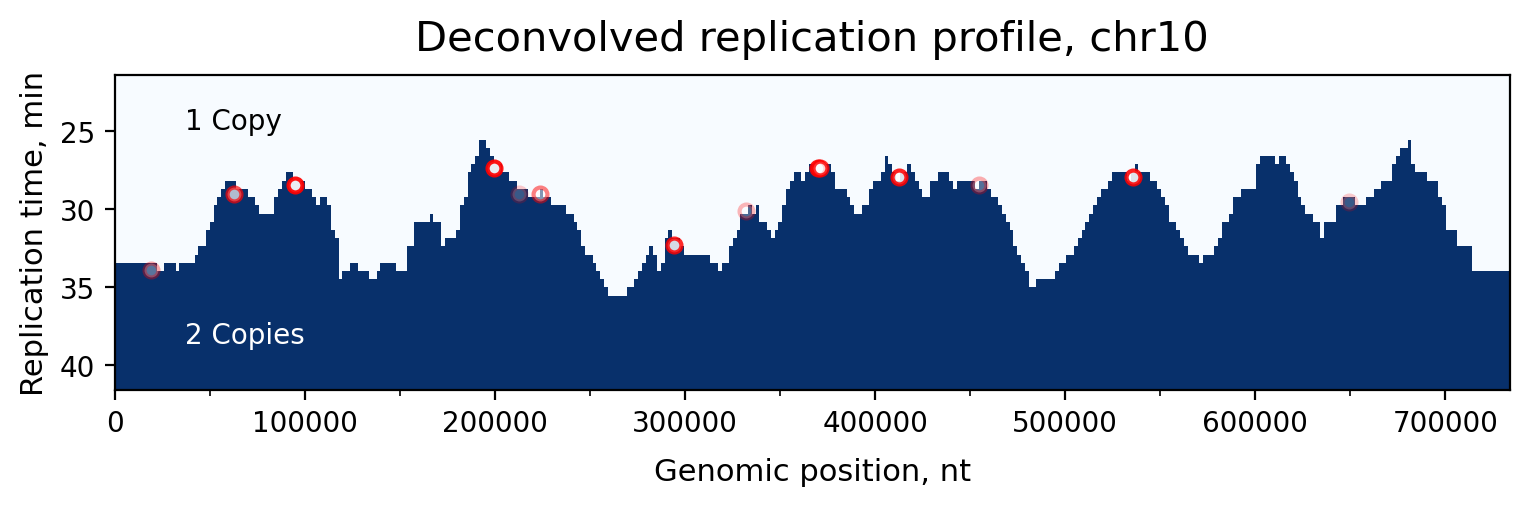

In [196]:
figures.plot_replication_profile_example()
save_figure_for_paper('output/figures/Copy_Correction/Replication_Deconvolution_chr10.png')

# Chromatin Analysis

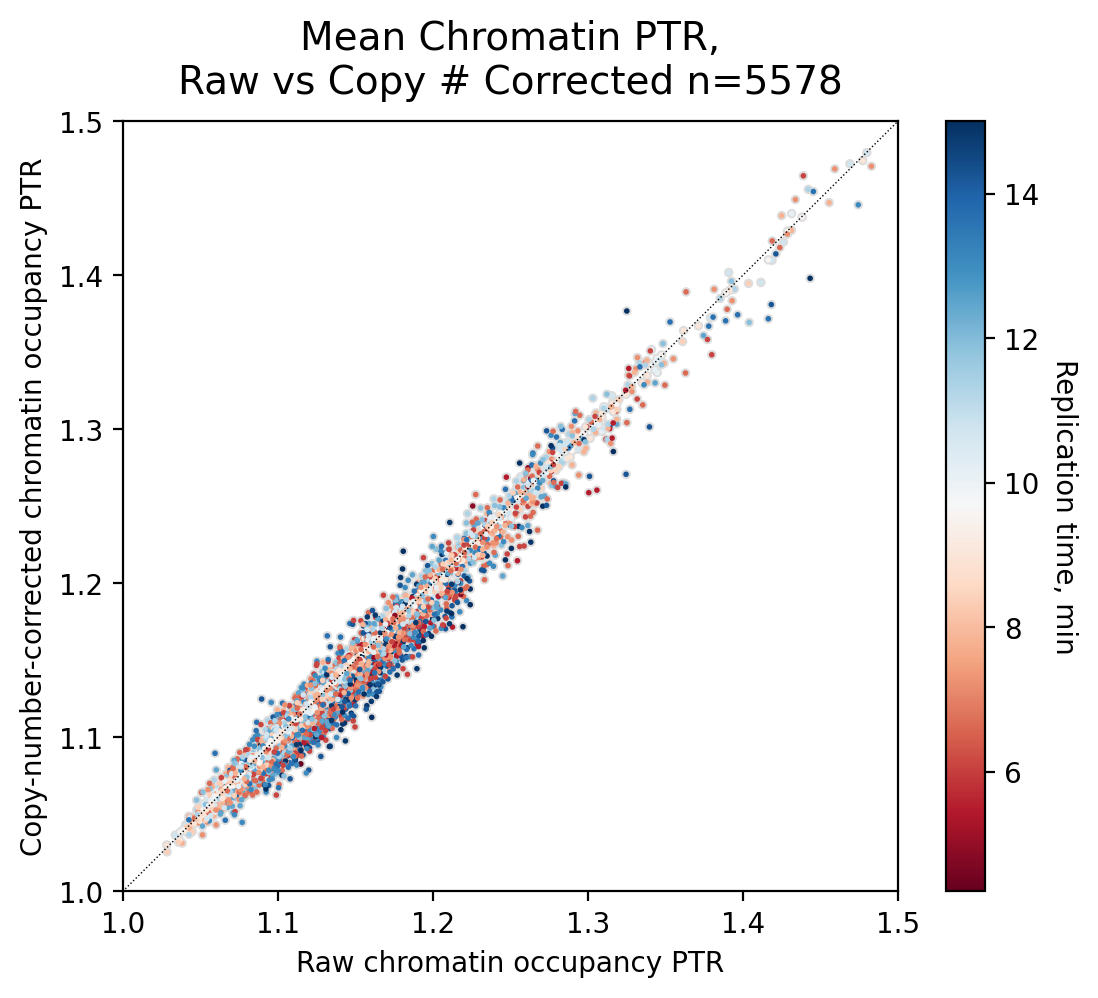

In [594]:
# Selected genes based on increase/decrease in PTR
figures.selected_chrom_genes = []
figures.plot_chrom_ptr_correction()

save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_PTR.png')

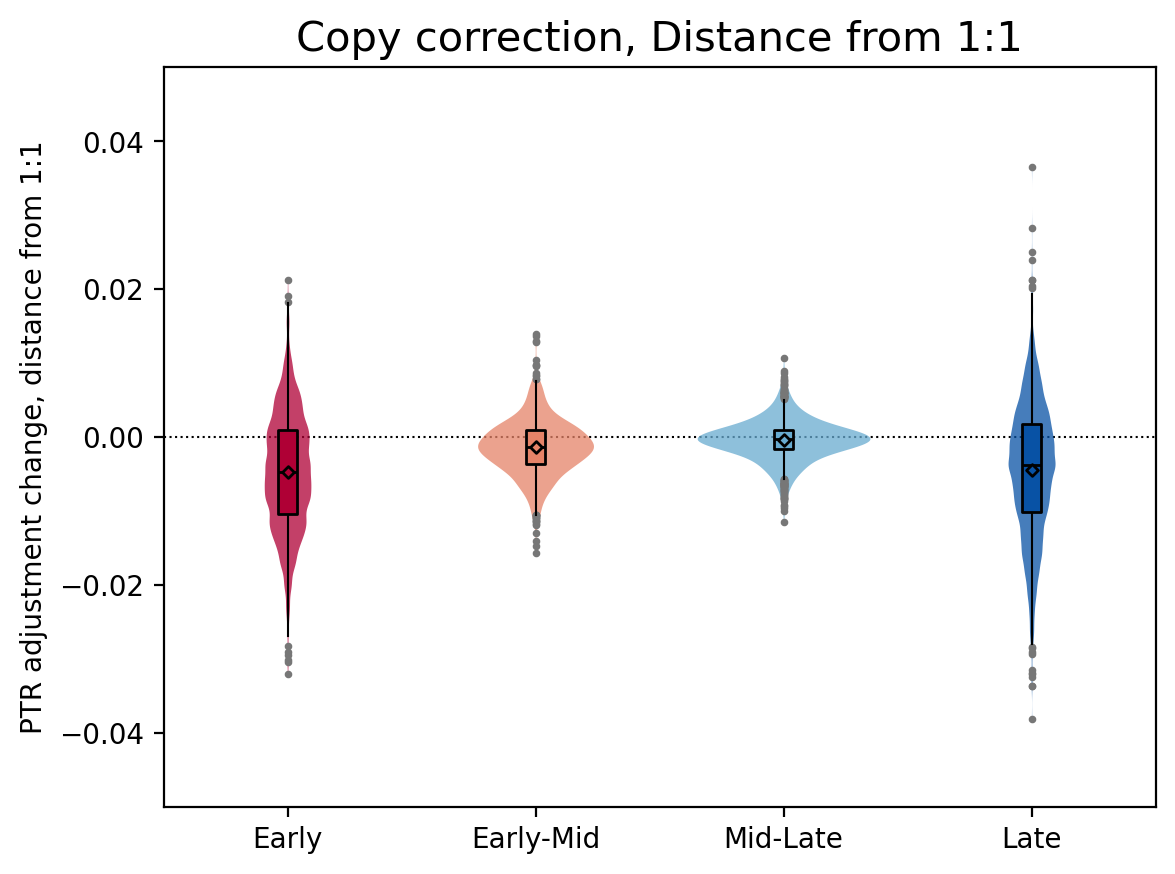

In [598]:
figures.plot_violin_ptr_11()
save_figure_for_paper('output/figures/Copy_Correction/Copy_Correction_Chromatin_PTR_Violins.png')

In [599]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

# Let's examine the PTRs for the gene expression to get an idea of the
# cell cycle regulated gene terms
gene_expression_dir = 'output/deconvolve_sharedg1_0066_cc_2024_06_13/gene_expression/'
gene_expression_a = GeneExpressionAnalysis(gene_expression_dir)
gene_expression_a.compute_ptrs()

0

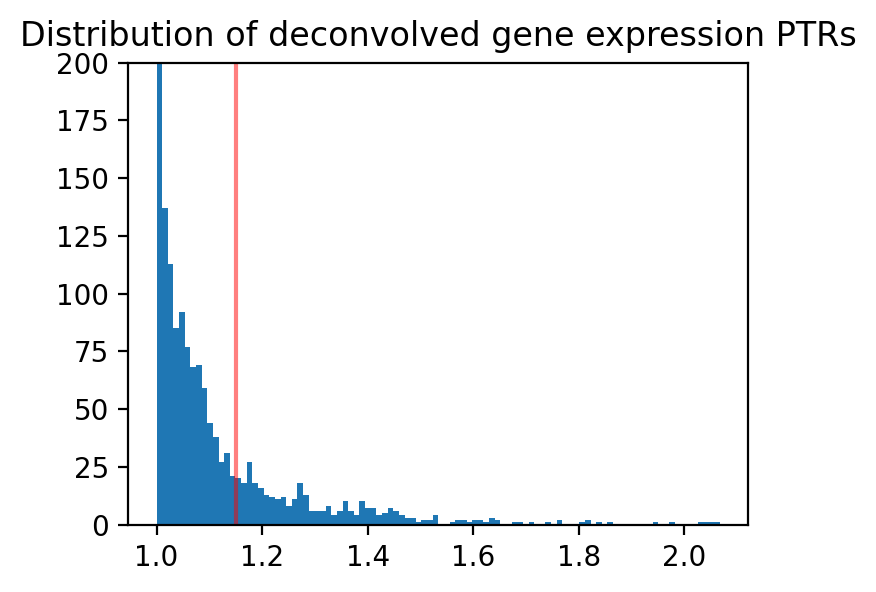

In [600]:
plt.figure(figsize=(4, 3))
plt.hist(gene_expression_a.gene_ptrs_df['ptr'], bins=100)
plt.ylim(0, 200)
thresh = 1.15
plt.axvline(thresh, c='red', alpha=0.5)
plt.title("Distribution of deconvolved gene expression PTRs")
0

In [601]:
highest_cycling_expression = gene_expression_a.gene_ptrs_df[gene_expression_a.gene_ptrs_df.ptr > thresh]
len(highest_cycling_expression)

350

In [602]:
from src.gene_ontology import GeneOntology
gene_ontology = GeneOntology()

data/go.obo: fmt(1.2) rel(2018-08-29) 47,313 Terms


In [603]:
selected_genes = highest_expression_ptrs
selected_genes = selected_genes.join(sgd_rows[['name']])

In [604]:
selected_orfs = selected_genes['name'].values

In [605]:
gene_ontology.run_go(selected_orfs)

In [606]:
gene_ontology.results_sig_df.head(2)

,id,name,pop_count,pop_n,study_count,study_n,pop_items,study_items,fdr_bh,bonferroni
0,GO:0031298,replication fork protection complex,25,5578,13,200,"MCM7,HTB2,MCM6,PSF3,CSM3,HTA2,TOF1,HTA1,SPT16,...","HHF1,MCM7,HTB1,HTB2,HTA2,MRC1,CDC45,HTA1,CTF4,...",1.426114e-09,1.426114e-09
1,GO:0005935,cellular bud neck,112,5578,22,200,"YOR304C-A,MMR1,DSE3,CHS3,PBS2,RSR1,RHO1,MLC1,A...","MMR1,DSE3,DBF2,SPH1,SHE1,MOB1,TOS2,PCL9,NIS1,B...",6.425586e-08,1.285117e-07


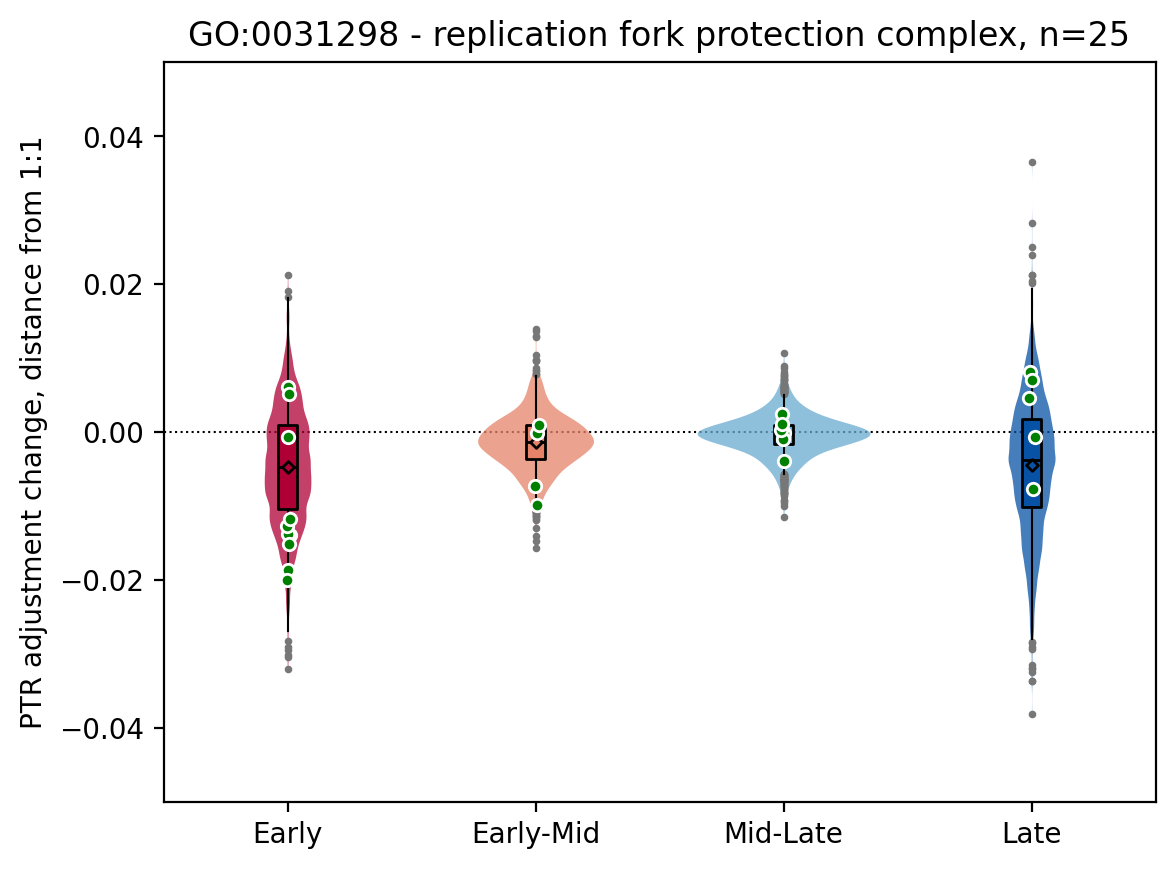

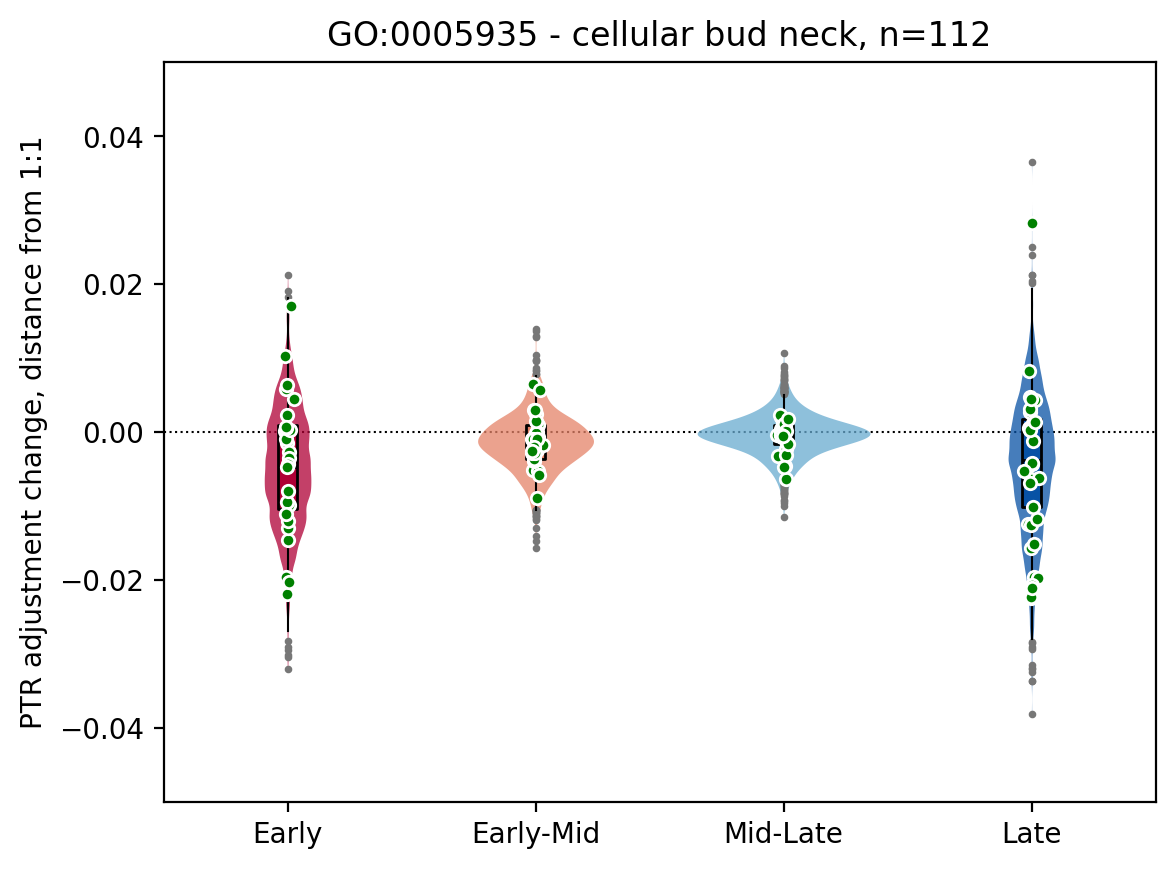

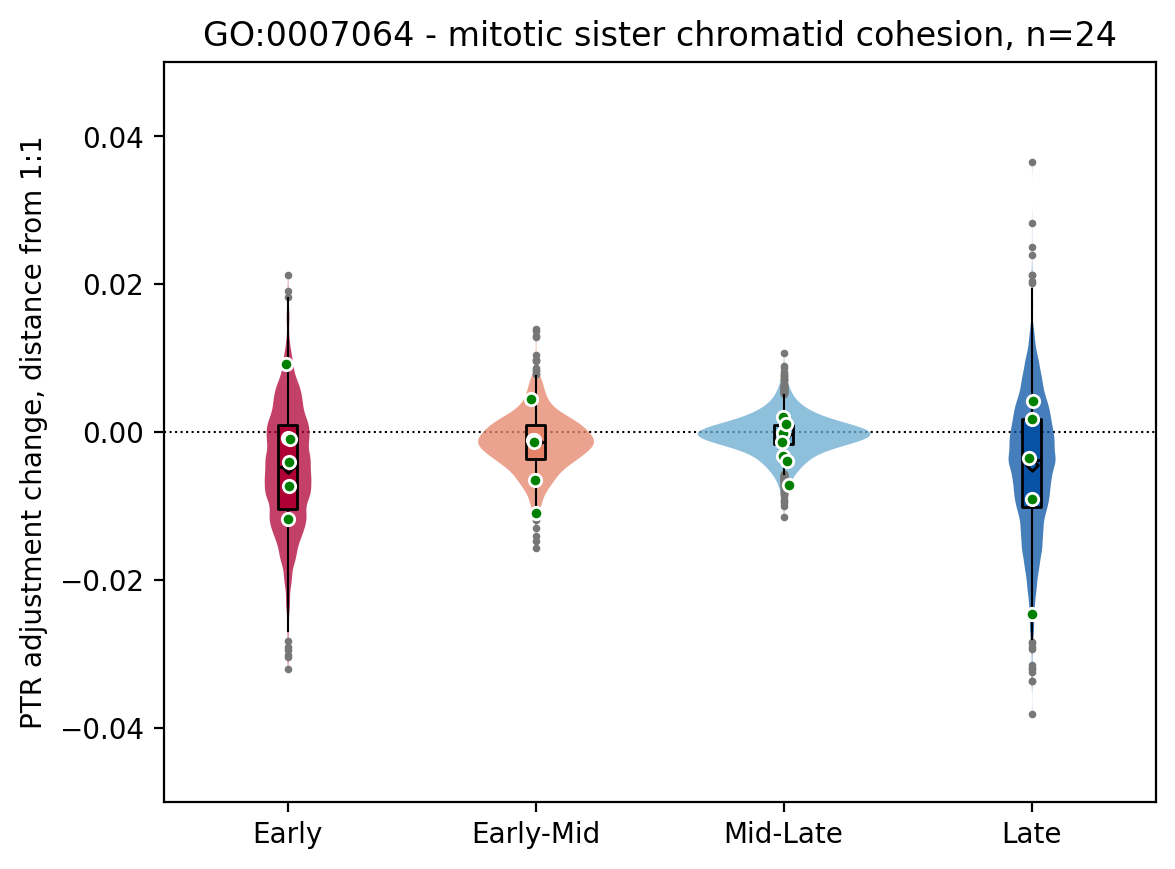

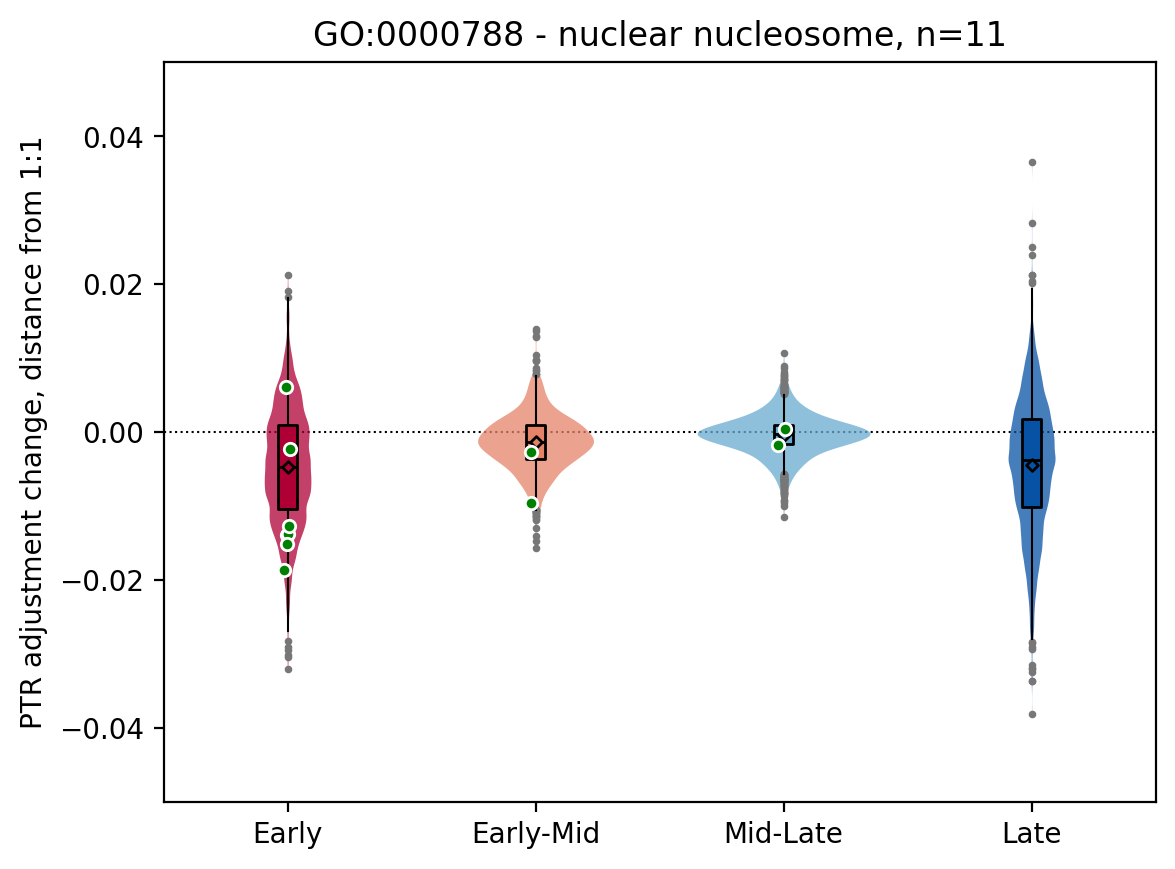

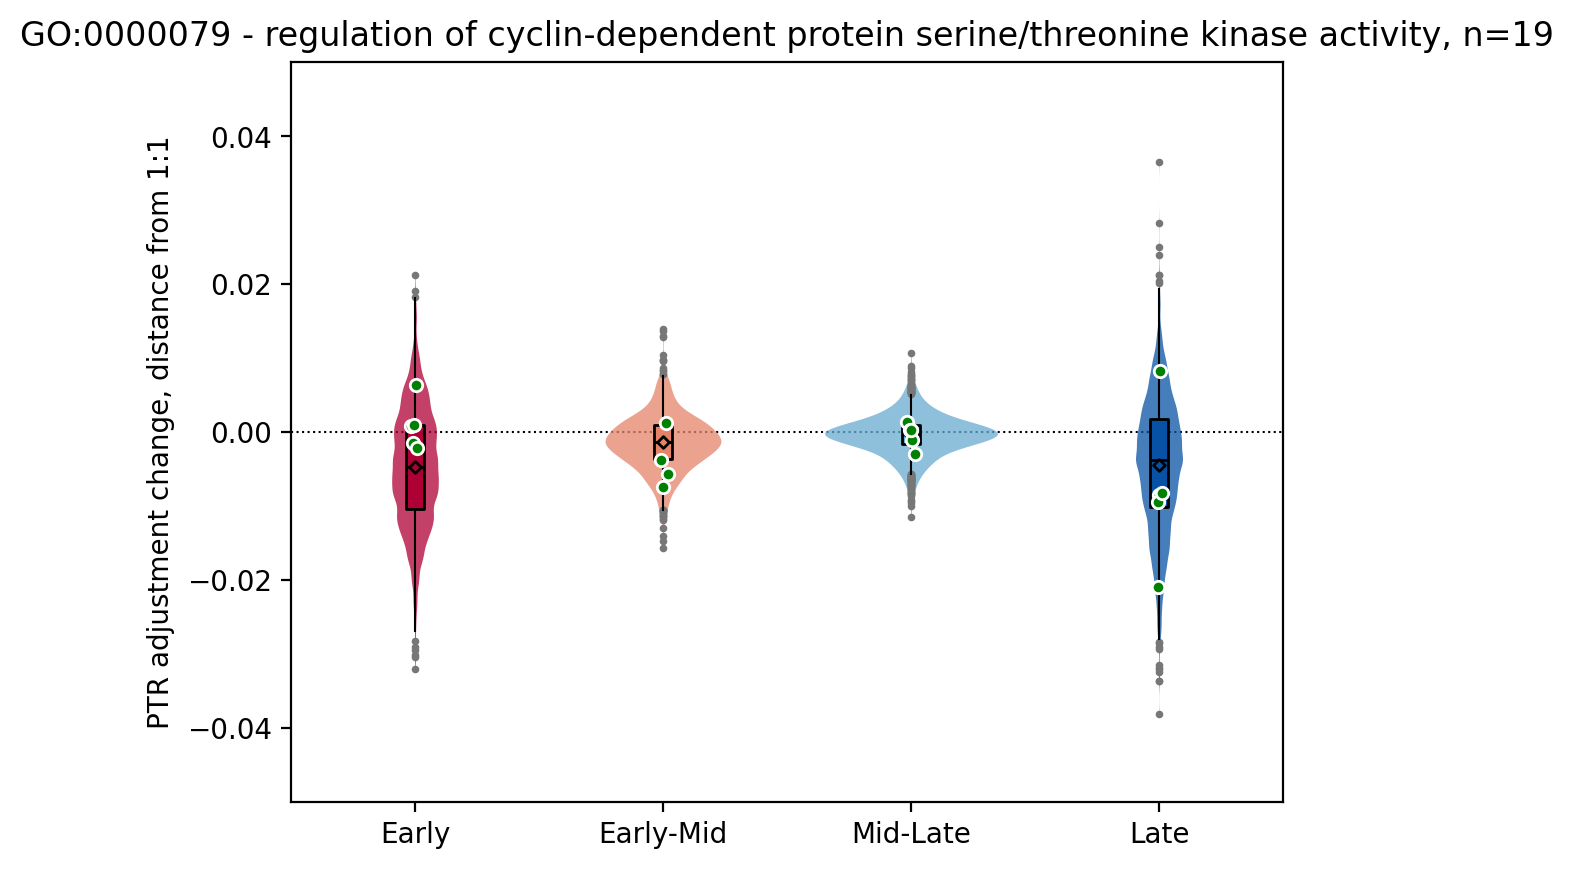

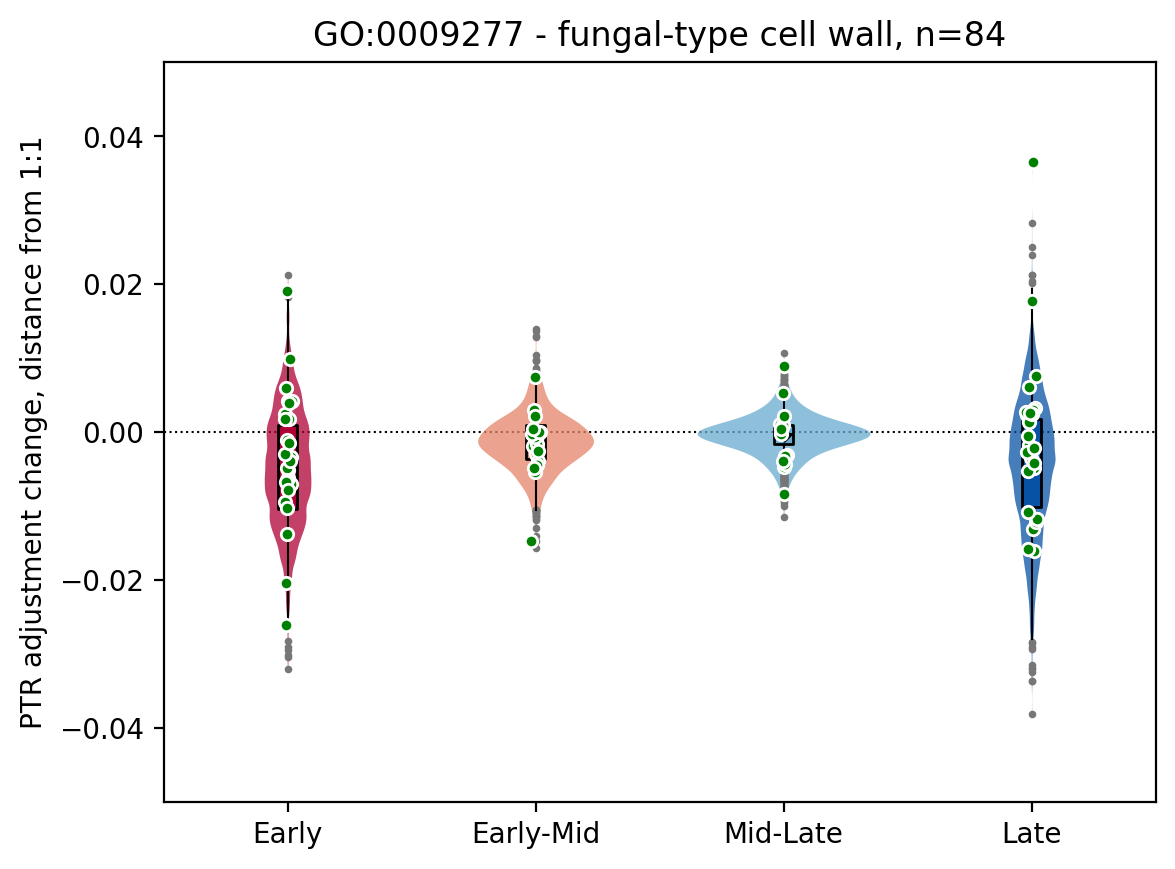

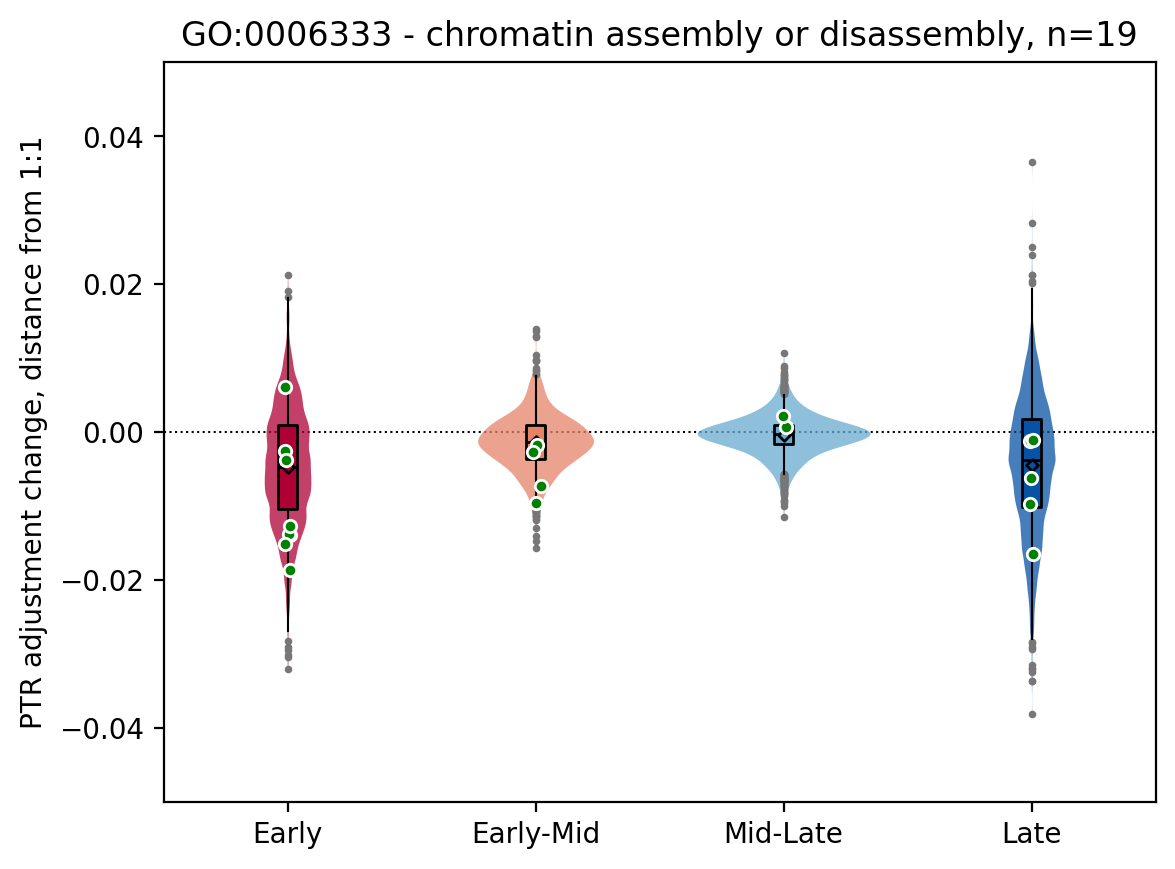

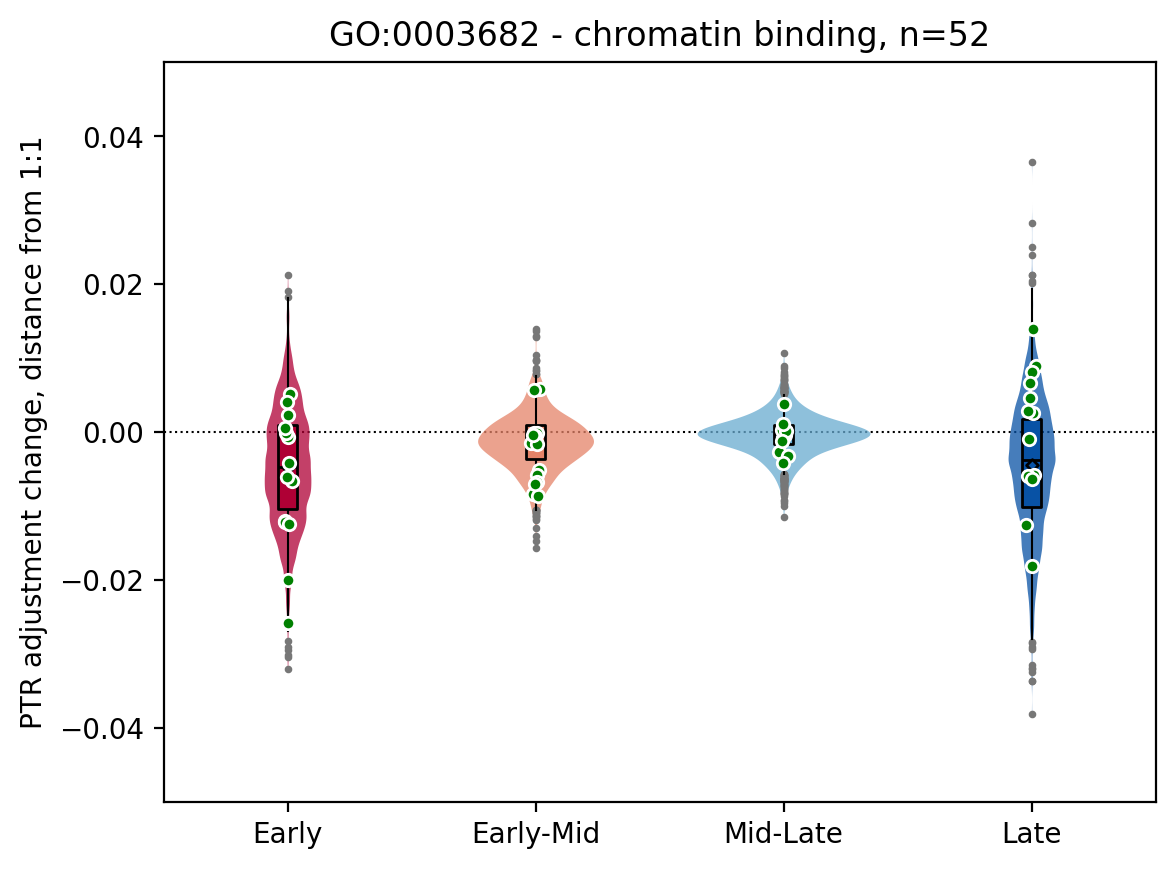

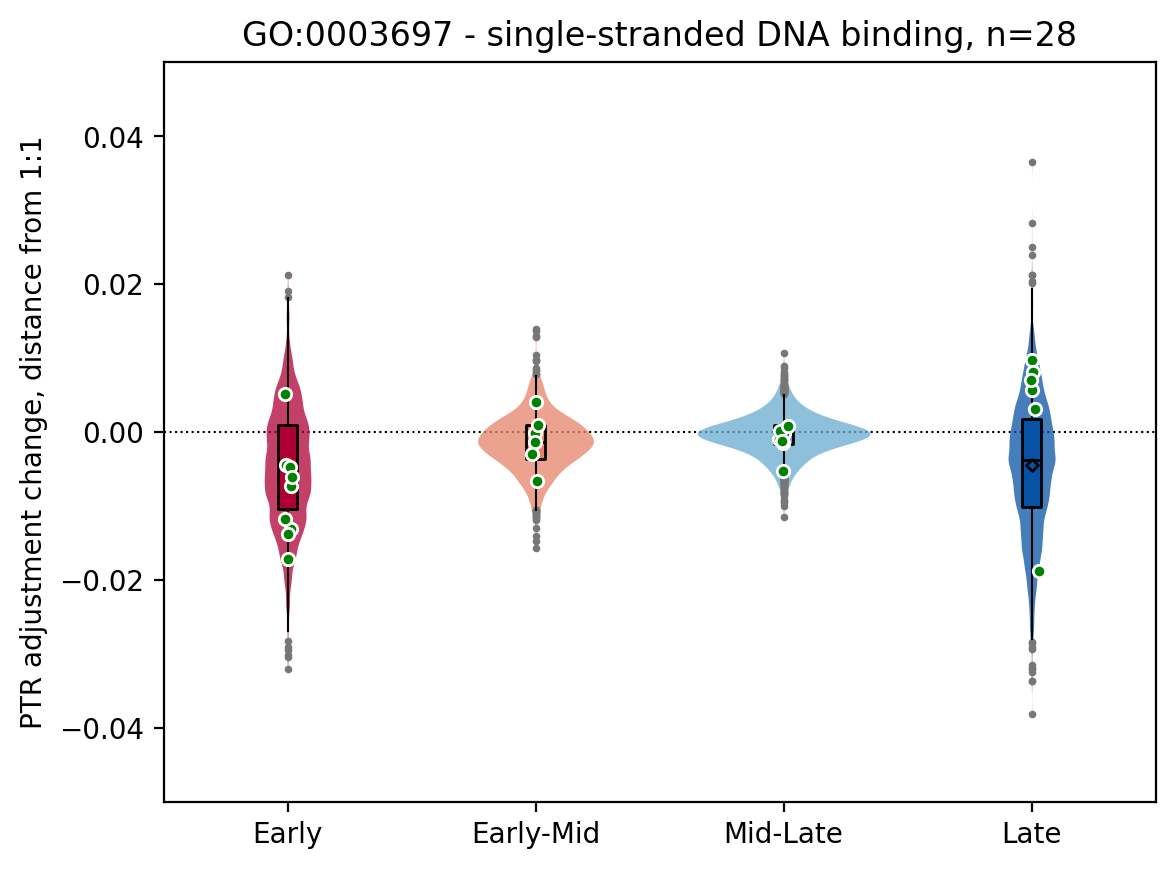

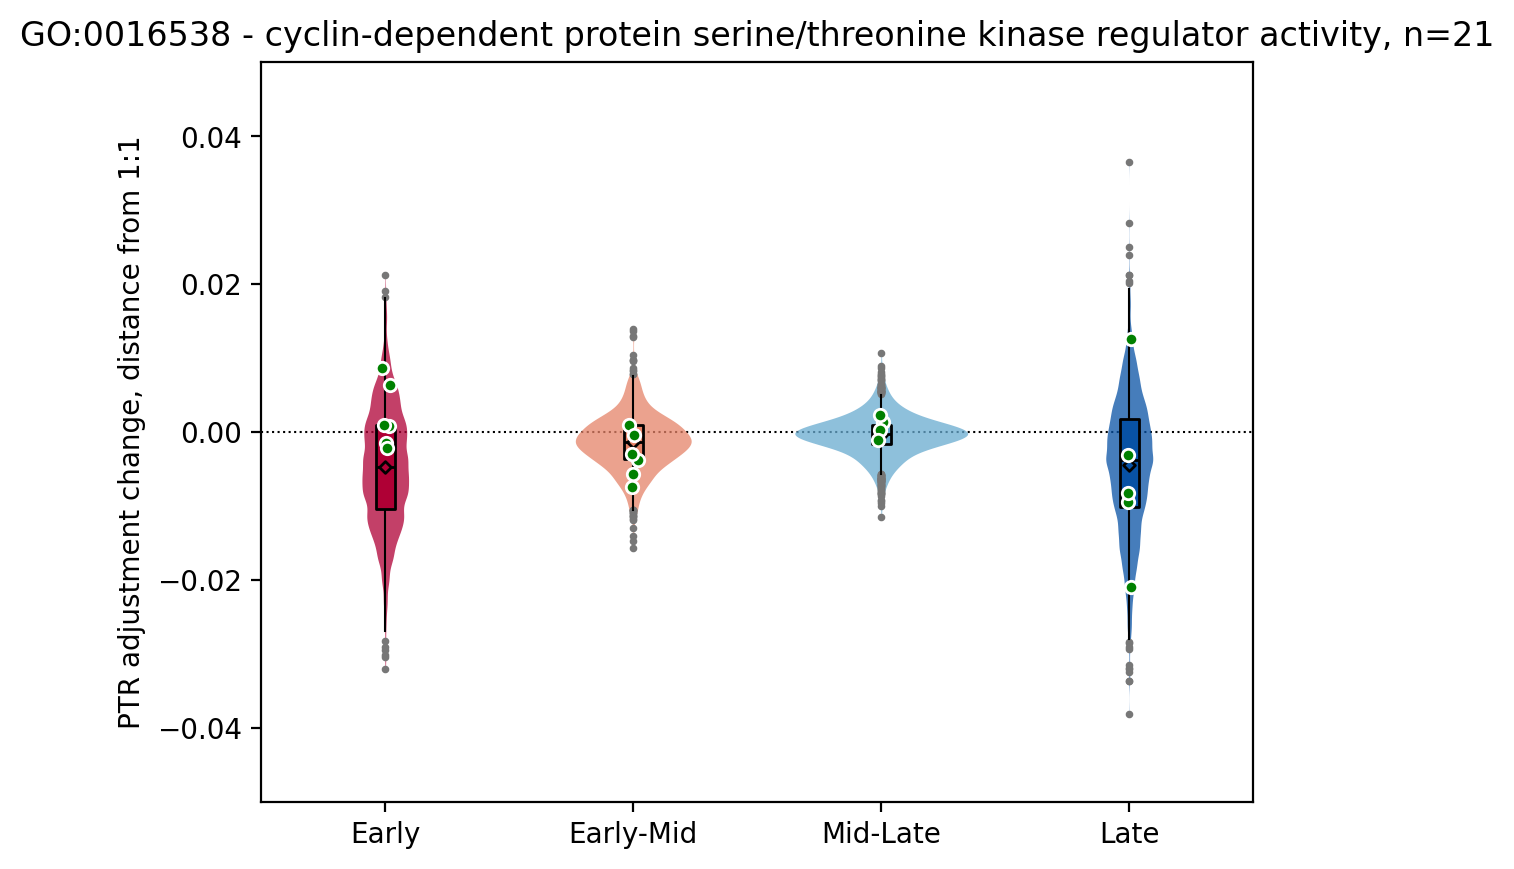

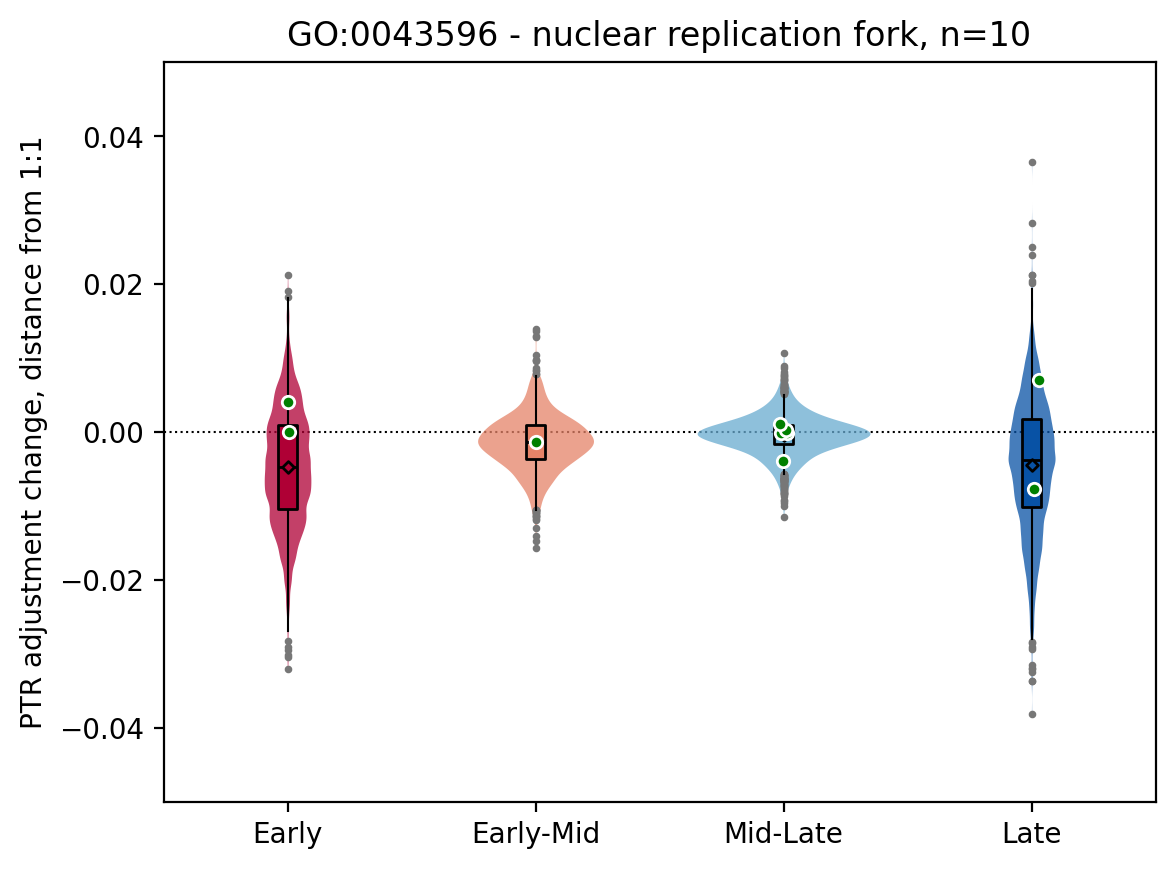

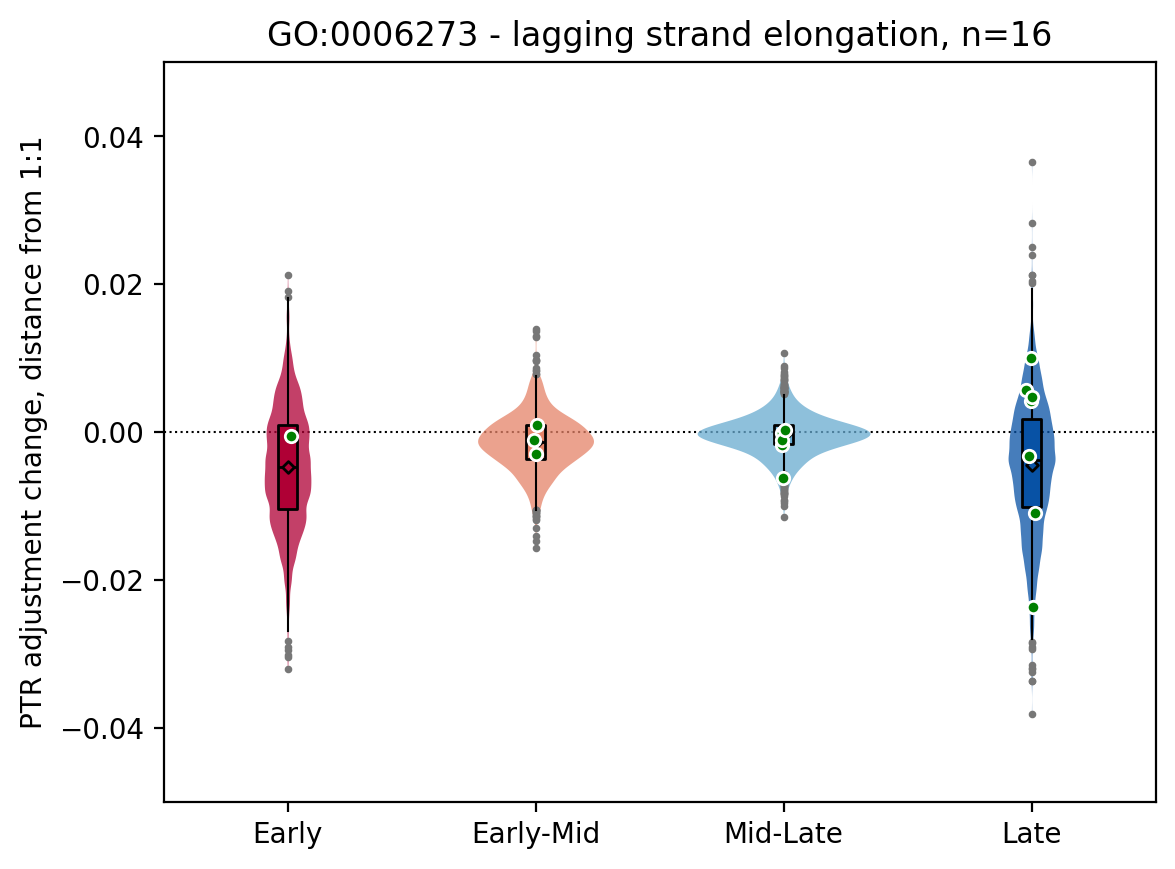

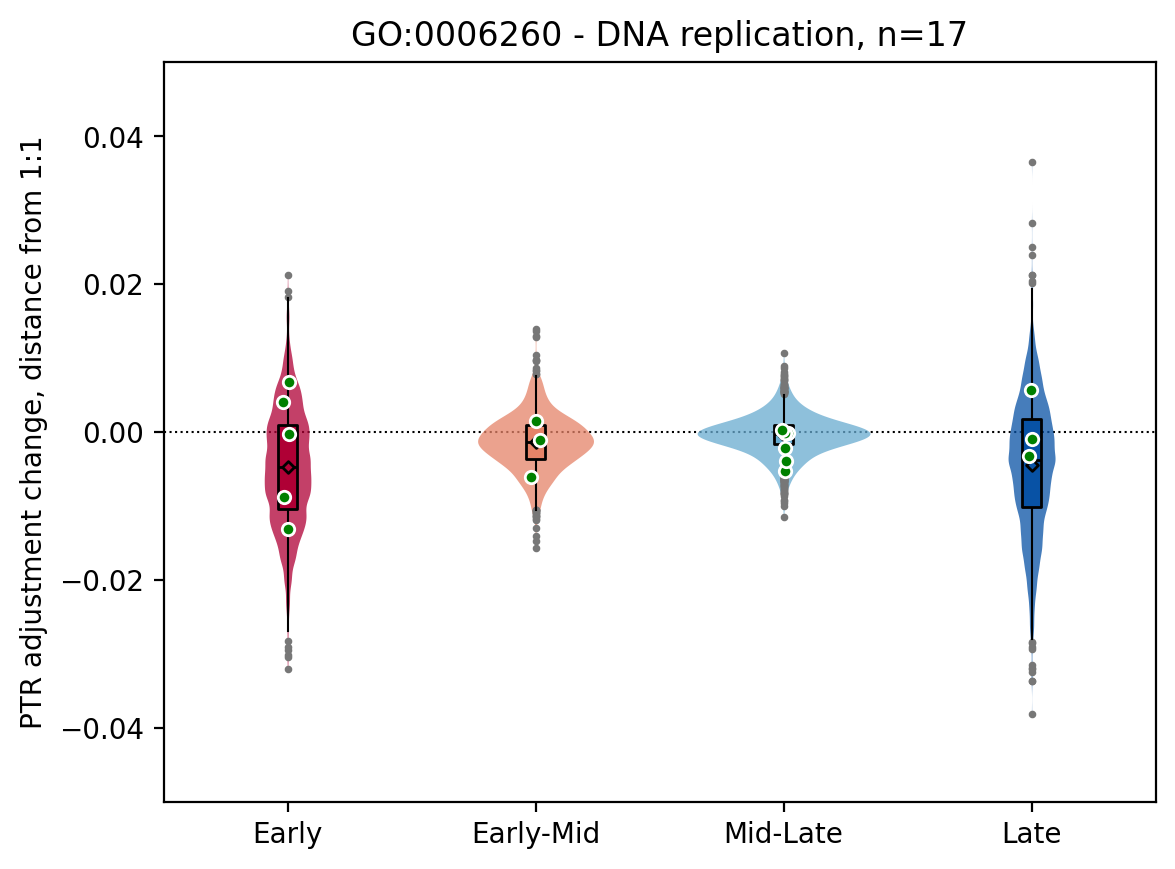

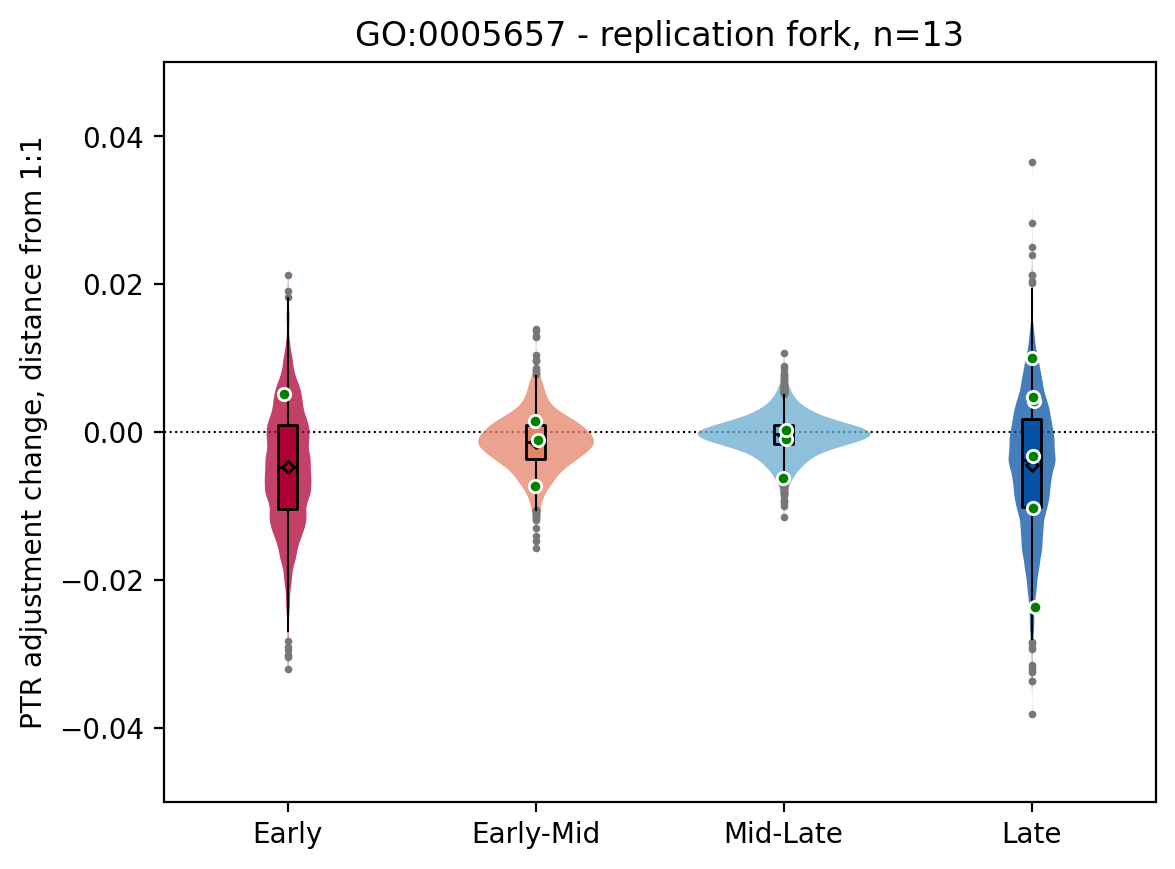

In [608]:

from src.gene_ontology import genes_for_go

for _, go_row in gene_ontology.results_sig_df.iterrows():
    go_term = go_row['name']
    go_id = go_row['id']

    # Get the example gene orfs for plotting
    example_genes, _ = genes_for_go(gene_ontology.orfs_with_go, go_id)
    example_orfs = example_genes.index

    from scipy.stats.distributions import norm

    figures.plot_violin_ptr_11(selected_genes)

    # --------

    vp = figures.violin_plotter
    selected_df = vp.dfs_to_plot[0].loc[example_orfs]

    x, y = selected_df.group_id, selected_df.distance_11

    x = x + norm.rvs(loc=0, scale=0.01, size=len(x))
    plt.scatter(x, y, s=20, zorder=100, edgecolor='white', facecolor='green')
    
    go_term_title = f"{go_id} - {go_term}, n={len(example_orfs)}"
        
    plt.title(go_term_title)

    go_save_title = go_term.replace(' ', '_')[0:13]
    save_figure_for_paper(f'output/figures/Copy_Correction/copy_chrom_go_{go_save_title}.png')
    plt.show()

In [615]:
sel, _ = genes_for_go(gene_ontology.orfs_with_go, "GO:0000079")
len(sel)

19

In [616]:
sel, _ = genes_for_go(gene_ontology.orfs_with_go, "GO:0016538")
len(sel)


21